In [2]:
#----------IMPORT LIBRARIES-------------
import numpy as np 
from math import ceil
from scipy import stats
from scipy.integrate import quad
import pandas as pd
import matplotlib.pyplot as plt

limit=1000000 #limit under which we look for primes

primes_long = pd.read_csv("/Users/admin/Downloads/numbers.csv") #opens the list of all primes we are looking for
primes_long["value"] = pd.to_numeric(primes_long["value"]).astype(int) #converts numbers to integers
primes = primes_long[primes_long["value"] < limit]['value'].tolist() #cuts the list to the required limit

#finds twin primes in list of all primes
def find_twin_primes(primes):
    prime_set = set(primes)
    return [(p, p + 2) for p in primes if (p + 2) in prime_set]


twin_lower=find_twin_primes(primes) #finds the smallest twin in pair


def calculate_bin_size(twin_lower): #calculates the bin size, so that there are at least 5 primes in a bin
  min_counts_per_bin=5
  sorted_twins = sorted([p for p, _ in twin_lower])
  bin_size=0
  for i in range(len(sorted_twins) - min_counts_per_bin):
    current_gap = sorted_twins[i + min_counts_per_bin] - sorted_twins[i]
        
    if current_gap > bin_size:
      bin_size= current_gap       
  return ceil(bin_size)



 
#sorts twin primes in bins
def count_primes_in_bins (twin_lower, num_bins, bin_size): 
    bin_labels = [] #range if each bin
    twin_prime_counts = [] #how many twin primes in the bin
  
 
    for i in range(num_bins):
        lo = 2 if i==0 else i * bin_size #lower bin limit
        hi = (i + 1) * bin_size #higher bin limit
        twin_prime_counts.append(sum(1 for p, _ in twin_lower if lo <= p <= hi))
        bin_labels.append(f"{lo}-{hi}")
    observed_values=twin_prime_counts
 
    return bin_labels, observed_values

#Hardy-Littlewood Conjecture
#sorts expected data in bins
def hardy_littlewood_conjecture(num_bins, bin_size):
  C2=0.6601618158
  expected_values=[]
  
  def integrand(t): #function inside integral
    return 1/(np.log(t)**2)
  
  
  for i in range (num_bins): #calculates the area under the curve for each bin
    lo=2 if i==0 else i*bin_size
    hi=(i+1)* bin_size
   
    area,_=quad(integrand,lo, hi)
    expected=2*C2*area
    expected_values.append(expected)
  return expected_values

#Goodnes of fit test
def chi_square_goodness_of_fit(observed_values, expected_values):
  statistic=0
  significance_level=0.05 
  for i in range (len(observed_values)): #loops through the prime number values
    statistic=statistic+(np.square(observed_values[i]-expected_values[i])/expected_values[i]) #chi squared statistic formula

  df=len(observed_values)-1
  p_value=stats.chi2.sf(statistic, df) #calculates p_value
  print(f"Chi-square statistic: {statistic:.4f}, p-value: {p_value:.4f}, df: {df}")
  if p_value>significance_level:
    print("Conclusion: Fail to reject H0")
  else:
    print("Conclusion: Reject H0")


bin_size=calculate_bin_size(twin_lower)
num_bins = ceil(limit/bin_size)
labels, observed_values = count_primes_in_bins(twin_lower, num_bins, bin_size)
for i in range(num_bins):
    print(f"Bin {labels[i]}: {observed_values[i]} twin primes")

expected_values=hardy_littlewood_conjecture(num_bins, bin_size)

print()
print("H0= there is no significant difference between the distribution of twin primes and Hardy-Littlewood Conjecture ")
print("H1= there is significant difference between the distribution of twin primes and Hardy-Littlewood Conjecture ")
chi_square_goodness_of_fit(observed_values, expected_values)




Bin 2-2436: 72 twin primes
Bin 2436-4872: 52 twin primes
Bin 4872-7308: 41 twin primes
Bin 7308-9744: 37 twin primes
Bin 9744-12180: 37 twin primes
Bin 12180-14616: 31 twin primes
Bin 14616-17052: 28 twin primes
Bin 17052-19488: 37 twin primes
Bin 19488-21924: 37 twin primes
Bin 21924-24360: 32 twin primes
Bin 24360-26796: 23 twin primes
Bin 26796-29232: 34 twin primes
Bin 29232-31668: 26 twin primes
Bin 31668-34104: 37 twin primes
Bin 34104-36540: 31 twin primes
Bin 36540-38976: 27 twin primes
Bin 38976-41412: 23 twin primes
Bin 41412-43848: 27 twin primes
Bin 43848-46284: 24 twin primes
Bin 46284-48720: 26 twin primes
Bin 48720-51156: 34 twin primes
Bin 51156-53592: 28 twin primes
Bin 53592-56028: 22 twin primes
Bin 56028-58464: 31 twin primes
Bin 58464-60900: 23 twin primes
Bin 60900-63336: 18 twin primes
Bin 63336-65772: 27 twin primes
Bin 65772-68208: 21 twin primes
Bin 68208-70644: 29 twin primes
Bin 70644-73080: 29 twin primes
Bin 73080-75516: 19 twin primes
Bin 75516-77952: 24 

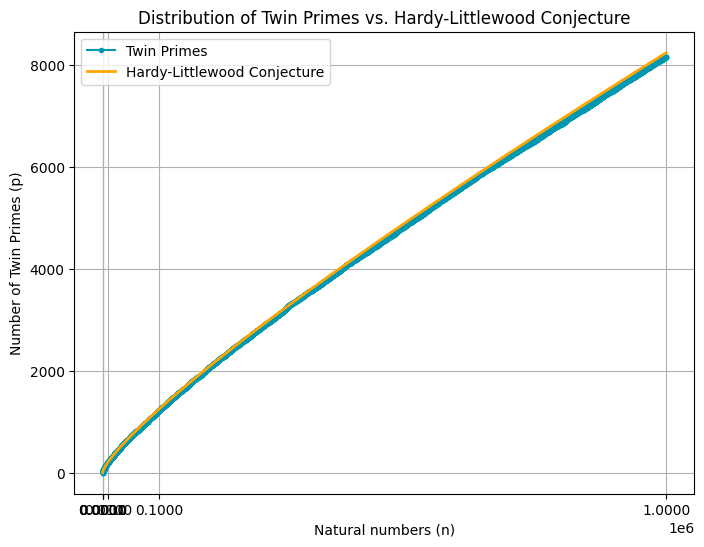

In [3]:
# Twin Prime Visualization
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


def hardy_littlewood_conjecture(x):
    C2=0.6601618158

    def integrand(t): #function inside integral
        return 1/(np.log(t)**2)
   
    area,_=quad(integrand,2, x)
    expected=2*C2*area
    return expected

# smooth x values from 2 to limit on a log scale
x_hl = np.logspace(np.log10(2), np.log10(limit), 500)
y_hl = [hardy_littlewood_conjecture(x) for x in x_hl]

xp = [p for p, _ in twin_lower]
yp= range(1, len(xp)+1)
# The circular prime list supplemented with R19 and R23 and the number of primes list (just the length of xp)
plt.figure(figsize=(8,6))
#plt.xscale('log')
#plt.yscale('log')
plt.title('Distribution of Twin Primes vs. Hardy-Littlewood Conjecture')
plt.xticks([1e1, 1e2, 1e3, 1e4, 1e5, 1e6])
plt.xlabel('Natural numbers (n)')
plt.ylabel('Number of Twin Primes (p)')
plt.plot(xp,yp, marker='.', label='Twin Primes', color='#0097b2')
plt.plot(x_hl, y_hl, label='Hardy-Littlewood Conjecture', color='orange', linewidth=2)
plt.legend()
plt.grid('0')
# Scaling customizing and adding extra information
plt.show()